# **DATA MODELING AND MODEL EVALUATION**

---

## **1. Import Libraries**

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import time

# Scikit-learn utilities for evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Import custom models implemented from scratch
from utils import Perceptron, LogisticRegression 
from utils import BinaryLogisticRegression
from utils import OneVsRestClassifier, OneVsOneClassifier, SoftmaxRegression

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

## **2. Load Data for Model**

Toàn bộ quá trình làm sạch, xử lý ngoại lai và chuẩn hóa (Standardization) đã được thực hiện triệt để ở giai đoạn *EDA & Preprocessing*. 

Dữ liệu sạch đã được phân chia theo tỷ lệ chuẩn và lưu trữ an toàn trong thư mục `data/processed/`. Tại bước này, chúng ta chỉ việc load các tập tin CSV, tách biệt ma trận biến độc lập ($X$) và vector mục tiêu ($y$). Cách tổ chức mã nguồn này giúp Notebook huấn luyện trở nên gọn gàng và triệt tiêu hoàn toàn rủi ro rò rỉ dữ liệu giữa tập Train và tập Test.

In [2]:
# Define file paths
train_path = '../../data/processed/Room_Occupancy_train.csv'
val_path = '../../data/processed/Room_Occupancy_val.csv'
test_path = '../../data/processed/Room_Occupancy_test.csv'

# Load the datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Define the target variable
target_col = 'Room_Occupancy_Count'

# Split features and target labels
X_train_scaled = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_val_scaled = val_df.drop(columns=[target_col]).values
y_val = val_df[target_col].values

X_test_scaled = test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Display the shape of the datasets
print(f"Training set shape:   {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Testing set shape:    {X_test_scaled.shape}")

Training set shape:   (6077, 31)
Validation set shape: (2026, 31)
Testing set shape:    (2026, 31)


## **3. Logistic Regression**

### 3.1. Mathematical Foundations: Gradients, Jacobians, and Hessians

Để các thuật toán tối ưu hóa như Gradient Descent hay Newton-Raphson có thể cập nhật trọng số hiệu quả, việc tính toán chính xác đạo hàm bậc nhất (Gradient) và bậc hai (Hessian) là bắt buộc. Dưới đây là cơ sở giải tích ma trận được áp dụng trực tiếp vào mã nguồn của dự án.

#### 1. Binary Logistic Regression (Sigmoid Activation)

Đối với bài toán phân lớp nhị phân, mô hình sử dụng hàm kích hoạt Sigmoid.
* *Hàm dự đoán (Forward Pass):* $$y_n = \sigma(w^\top x_n) = \frac{1}{1 + e^{-w^\top x_n}}$$
* *Đạo hàm bậc 1 (Gradient của Cross-entropy Loss):* $$\nabla_w E = \sum_{n=1}^N (y_n - t_n)x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian cho Newton-Raphson):* Khai thác thông tin độ cong của hàm mất mát:
  $$\mathbf{H} = \Phi^\top \mathbf{R} \Phi$$
  *(Trong đó, $\mathbf{R}$ là ma trận đường chéo với các phần tử $R_{nn} = y_n(1-y_n)$).*

#### 2. Multinomial Logistic Regression (Softmax Activation)

Đối với bài toán đa lớp, mô hình sử dụng hàm Softmax để tính phân phối xác suất chung.
* *Hàm dự đoán cho lớp $k$:* Với $a_{nk} = w_k^\top x_n$ là điểm số (logit) tĩnh:
  $$y_{nk} = p(\mathcal{C}_k | x_n) = \frac{\exp(a_{nk})}{\sum_j \exp(a_{nj})}$$
* *Ma trận Jacobian của Softmax:* Đạo hàm của xác suất đầu ra $y_i$ theo logit $a_j$ sinh ra một ma trận Jacobian. Đây là bước then chốt nhất trong chuỗi đạo hàm (chain rule):
  $$\frac{\partial y_i}{\partial a_j} = y_i(\delta_{ij} - y_j)$$
  *(Với $\delta_{ij}$ là Kronecker delta: bằng $1$ nếu $i=j$, bằng $0$ nếu $i \neq j$).*
* *Đạo hàm bậc 1 (Gradient):* $$\nabla_{w_k} E = \sum_{n=1}^N (y_{nk} - t_{nk})x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian của Softmax):* Đạo hàm chéo của Loss theo cặp trọng số $w_k$ và $w_j$:
  $$\nabla_{w_k} \nabla_{w_j} E = \sum_{n=1}^N y_{nk}(\delta_{kj} - y_{nj}) x_n x_n^\top$$

In [3]:
# EXAMPLE: SOFTMAX JACOBIAN ILLUSTRATION

# Initialize model (only for utility functions; no training required)
demo_model = SoftmaxRegression()

# Assume a single input sample producing logits for 3 classes (K = 3)
# Note: _softmax expects input shape (N, K)
sample_logits = np.array([[2.0, 1.0, 0.1]])

# Compute softmax probabilities (numerically stable)
probabilities = demo_model._softmax(sample_logits)[0]
# Compute Softmax Jacobian matrix (vectorized form)
jacobian_matrix = np.diag(probabilities) - np.outer(probabilities, probabilities)

# Rresults
print("1. Input logits (a):")
print(sample_logits[0])
print("\n2. Softmax probabilities (y):")
print(np.round(probabilities, 4))
print("\n3. Softmax Jacobian matrix (∂y_i / ∂a_j):")
print(np.round(jacobian_matrix, 4))

1. Input logits (a):
[2.  1.  0.1]

2. Softmax probabilities (y):
[0.659  0.2424 0.0986]

3. Softmax Jacobian matrix (∂y_i / ∂a_j):
[[ 0.2247 -0.1598 -0.065 ]
 [-0.1598  0.1837 -0.0239]
 [-0.065  -0.0239  0.0889]]


**Phân tích ma trận Jacobian của Softmax:**

Kết quả thực nghiệm trên minh họa hoàn hảo các đặc tính toán học cốt lõi của hàm kích hoạt Softmax. Dựa vào ma trận Jacobian thu được, chúng ta có thể rút ra những nhận xét quan trọng sau:

1. **Đường chéo chính ($i = j$) luôn mang giá trị DƯƠNG:** Các phần tử nằm trên đường chéo (ví dụ: $\frac{\partial y_0}{\partial a_0} = 0.2247$) thể hiện đạo hàm của xác suất lớp $i$ theo chính logit của nó. Giá trị dương phản ánh mối quan hệ thuận biến: Khi điểm số (logit) của một lớp tăng lên, xác suất mô hình dự đoán cho lớp đó cũng sẽ tăng theo.

2. **Các phần tử ngoài đường chéo ($i \neq j$) luôn mang giá trị ÂM:** Các phần tử còn lại (ví dụ: $\frac{\partial y_1}{\partial a_0} = -0.1598$) thể hiện sự tác động chéo. Đây chính là minh chứng cho *cơ chế cạnh tranh* của hàm Softmax. Do tổng xác suất của tất cả các lớp bị ràng buộc chặt chẽ phải bằng $1$ ($\sum y_i = 1$), sự gia tăng điểm số của lớp $0$ sẽ lập tức "hút" bớt không gian xác suất của lớp $1$ và lớp $2$, khiến đạo hàm mang dấu âm.

3. **Bảo toàn tổng xác suất:**
   Nếu để ý kỹ, tổng các giá trị trên bất kỳ cột nào của ma trận Jacobian đều xấp xỉ bằng $0$ (Ví dụ cột 0: $0.2247 - 0.1598 - 0.0650 \approx 0$). Điều này chứng minh rằng bất kỳ sự thay đổi nào về điểm số logit đầu vào cũng chỉ làm *phân phối lại* xác suất giữa các lớp, chứ không làm thay đổi tổng không gian xác suất ($=1$).

### **3.2 Problem Formulation & Target Transformation**

Theo yêu cầu của đồ án, nhóm cần đánh giá họ thuật toán hồi quy Logistic trên cả hai kịch bản: *phân lớp nhị phân* (để đối sánh thuật toán tối ưu Newton-Raphson) và *phân lớp đa lớp* (để đối sánh 3 chiến lược OvR, OvO, Softmax). 

Bộ dữ liệu *Room Occupancy Estimation* hiện tại cung cấp nhãn gốc là số lượng người cụ thể trong phòng ($y \in \{0, 1, 2, 3\}$). Để tuân thủ yêu cầu của đồ án mà không cần phải thay thế bằng một bộ dữ liệu khác, chúng em sẽ thiết lập hai bài toán học máy song song trên cùng một không gian đặc trưng:

1. **Bài toán nhị phân (Binary Classification):** Áp dụng phép biến đổi logic để gộp nhóm. Ta quy định nhãn `0` cho trạng thái phòng trống ($y = 0$) và nhãn `1` cho trạng thái có người ($y > 0$). Tập nhãn này sẽ đóng vai trò kiểm chứng sức mạnh của ma trận Hessian trong thuật toán Newton-Raphson.
2. **Bài toán đa lớp (Multiclass Classification):** Giữ nguyên không gian nhãn gốc với $K=4$ lớp. Tập nhãn này sẽ được sử dụng để phân tích sự đánh đổi về thời gian huấn luyện và độ chính xác giữa các chiến lược phân giải đa lớp (One-vs-Rest, One-vs-One) và tối ưu trực tiếp (Multinomial Softmax).

Dưới đây là mã nguồn thực hiện phép ánh xạ nhãn và kiểm tra phân bố của chúng trên tập huấn luyện:

In [4]:
# Convert labels to binary classification:
# 0 -> Empty room, 1 -> Occupied
y_train_binary = np.where(y_train > 0, 1, 0)
y_val_binary = np.where(y_val > 0, 1, 0)
y_test_binary = np.where(y_test > 0, 1, 0)

# Keep original labels for multiclass classification (e.g., 0, 1, 2, 3)
y_train_multi = y_train
y_val_multi = y_val
y_test_multi = y_test

# Display label distributions for sanity check
print("Binary label distribution (Train):", np.bincount(y_train_binary))
print("Multiclass label distribution (Train):", np.bincount(y_train_multi))

Binary label distribution (Train): [4470 1607]
Multiclass label distribution (Train): [4470  459  655  493]


### **3.3 Problem 1: Binary Classification (Empty Room vs. Occupied Room)**

**Mục tiêu:** Đánh giá và so sánh tốc độ hội tụ của hai phương pháp tối ưu hóa cốt lõi trong hồi quy Logistic: *Gradient Descent (GD)* (phương pháp tối ưu bậc 1) và *Newton-Raphson / IRLS* (phương pháp tối ưu bậc 2).

**Cơ sở lý thuyết:**
* Thuật toán **Newton-Raphson** khai thác thông tin độ cong của hàm mục tiêu thông qua ma trận đạo hàm bậc hai (Hessian), do đó có tốc độ hội tụ cực nhanh về mặt số vòng lặp $\mathcal{O}(\log(1/\epsilon))$. Tuy nhiên, nghịch đảo Hessian truyền thống có chi phí tính toán mỗi bước rất lớn $\mathcal{O}(NM^2 + M^3)$.
* Ngược lại, **Gradient Descent** chỉ dùng đạo hàm bậc nhất, mỗi bước cập nhật trọng số tốn rất ít thời gian nhưng lại yêu cầu hàng ngàn vòng lặp $\mathcal{O}(1/\epsilon)$ để hội tụ.

Dưới đây, chúng ta sẽ tiến hành huấn luyện hai mô hình này trên tập nhãn `y_binary` và ghi nhận lại lịch sử hàm mất mát (loss history) cùng thời gian thực thi (time history) tương ứng.

In [5]:
# 1. Initialize and train the model using Gradient Descent (GD)
print("Training Binary Logistic Regression using Gradient Descent (GD)...")
gd_model = BinaryLogisticRegression(method='gd', learning_rate=0.1, max_iter=2000, tol=1e-5)
gd_model.fit(X_train_scaled, y_train_binary)

# 2. Initialize and train the model using Newton-Raphson (IRLS)
print("Training Binary Logistic Regression using Newton-Raphson (IRLS)...")
newton_model = BinaryLogisticRegression(method='newton', max_iter=50, tol=1e-5)
newton_model.fit(X_train_scaled, y_train_binary)

Training Binary Logistic Regression using Gradient Descent (GD)...
Training Binary Logistic Regression using Newton-Raphson (IRLS)...


**Đánh giá tốc độ hội tụ**

Để quan sát rõ ràng sự đánh đổi (trade-off) giữa hai thuật toán, chúng ta tiến hành trực quan hóa kết quả trên hai trục độ đo:
1. **Loss vs. Epochs:** Đánh giá hiệu suất cập nhật trọng số sau mỗi bước lặp.
2. **Loss vs. Wall-clock time:** Đánh giá thời gian tính toán thực tế.

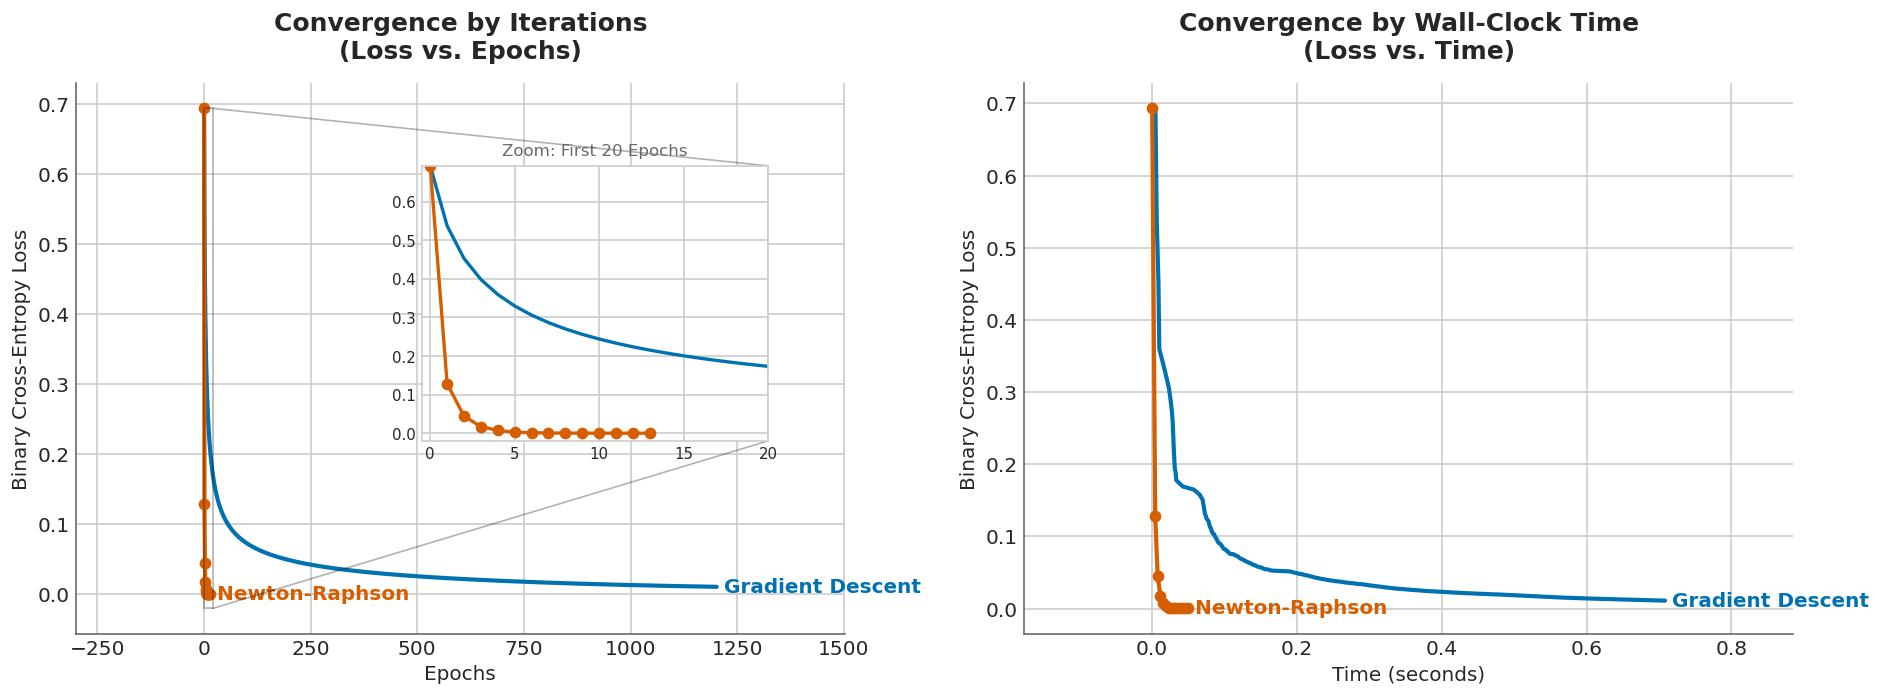

In [6]:
# VISUALIZATION CONFIGURATION
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_GD = '#0072B2'       # Blue
COLOR_NEWTON = '#D55E00'   # Dark orange
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# PLOT 1: LOSS VS. EPOCHS (WITH ZOOM-IN INSET)
ax1.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax1.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax1.text(len(gd_model.loss_history), gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax1.text(len(newton_model.loss_history), newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

# Inset plot: zoom into early training phase
axins = ax1.inset_axes([0.45, 0.35, 0.45, 0.5]) 
axins.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2)
axins.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2, marker='o', markersize=6)

# Focus on first 20 epochs
axins.set_xlim(-0.5, 20)
axins.set_ylim(bottom=-0.02, top=max(gd_model.loss_history[0], newton_model.loss_history[0]))
axins.set_title("Zoom: First 20 Epochs", fontsize=10, color='dimgray')
axins.tick_params(axis='both', labelsize=9)

ax1.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)
ax1.set_title("Convergence by Iterations\n(Loss vs. Epochs)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

# PLOT 2: LOSS VS. WALL-CLOCK TIME
ax2.plot(gd_model.time_history, gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax2.plot(newton_model.time_history, newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax2.text(gd_model.time_history[-1], gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax2.text(newton_model.time_history[-1], newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

ax2.set_title("Convergence by Wall-Clock Time\n(Loss vs. Time)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Time (seconds)", fontsize=12)
ax2.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

for ax in [ax1, ax2]:
    ax.margins(x=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('dimgray')
    ax.spines['left'].set_color('dimgray')
plt.tight_layout()
plt.show()

Dựa vào hai biểu đồ trên, chúng ta rút ra những kết luận quan trọng sau:
1. **Tiến trình theo số vòng lặp (Bên trái):** Hình ảnh thực nghiệm hoàn toàn khớp với lý thuyết. Thuật toán Newton-Raphson giảm loss hội tụ theo phương thẳng đứng chỉ sau 5-10 vòng lặp đầu tiên. Ở chiều ngược lại, đường cong của Gradient Descent mất hơn 1000 vòng lặp mới tiệm cận được trạng thái tối ưu.
2. **Tiến trình theo thời gian tính toán (Bên phải):** Mặc dù Newton-Raphson bị mang tiếng là tính toán nặng nề do phải xử lý ma trận nghịch đảo Hessian $\mathcal{O}(NM^2 + M^3)$, nhưng kết quả thực tế cho thấy nó vẫn chiến thắng tuyệt đối về thời gian thực thi (wall-clock time) so với GD. Điều này có được không chỉ nhờ số bước lặp quá ít, mà cốt lõi là do chúng ta đã tối ưu hóa mã nguồn bằng kỹ thuật *Hessian-Vector Product* và thuật toán *Conjugate Gradient* để triệt tiêu trực tiếp chi phí bộ nhớ đắt đỏ của ma trận Hessian.

### **3.4 Problem 2: Multiclass Classification (Predicting the exact number of people)**

**Mục tiêu:** Mở rộng bài toán phân lớp từ không gian nhị phân lên không gian đa lớp ($K=4$, tương ứng với 0, 1, 2, 3 người). Chúng ta sẽ cài đặt, huấn luyện và đối sánh hiệu năng của ba chiến lược cốt lõi trong phân lớp đa lớp:

1. **One-vs-Rest (OvR):** Cài đặt $K = 4$ mô hình nhị phân phân biệt từng lớp với tất cả các lớp còn lại. Quyết định cuối cùng dựa trên argmax của xác suất dự đoán.
2. **One-vs-One (OvO):** Cài đặt $K(K-1)/2 = 6$ mô hình nhị phân cho từng cặp lớp. Quyết định cuối cùng dựa trên cơ chế bỏ phiếu đa số.
3. **Softmax (Multinomial):** Khác biệt hoàn toàn với hai phương pháp trên (vốn là meta-estimators sử dụng thuật toán nhị phân), Softmax tối ưu hóa trực tiếp một ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$ thông qua hàm mất mát Categorical Cross-Entropy.

*Lưu ý thiết lập: Để đảm bảo tính công bằng về mặt thuật toán, cả OvR và OvO đều sẽ gọi thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu cực nhanh `Newton-Raphson`. Softmax sẽ dùng `Gradient Descent` truyền thống.*

In [7]:
print("\tTRAINING MULTICLASS")

# 1. ONE-VS-REST (OvR)
start_time_ovr = time.time()
ovr = OneVsRestClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovr.fit(X_train_scaled, y_train_multi)
time_ovr = time.time() - start_time_ovr
acc_ovr = accuracy_score(y_test_multi, ovr.predict(X_test_scaled))

# 2. ONE-VS-ONE (OvO)
start_time_ovo = time.time()
ovo = OneVsOneClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovo.fit(X_train_scaled, y_train_multi)
time_ovo = time.time() - start_time_ovo
acc_ovo = accuracy_score(y_test_multi, ovo.predict(X_test_scaled))


# 3. SOFTMAX (MULTINOMIAL LOGISTIC REGRESSION)
start_time_softmax = time.time()
softmax_model = SoftmaxRegression(learning_rate=0.1, max_iter=1000)
softmax_model.fit(X_train_scaled, y_train_multi)
time_softmax = time.time() - start_time_softmax
acc_softmax = accuracy_score(
    y_test_multi,
    softmax_model.predict(X_test_scaled)
)


# RESULTS TABLE
results = pd.DataFrame({
    "Strategy": ["One-vs-Rest (OvR)", "One-vs-One (OvO)", "Softmax (Multinomial)"],
    "Training Time (s)": [time_ovr, time_ovo, time_softmax],
    "Test Accuracy": [acc_ovr, acc_ovo, acc_softmax]
})
# Sort by accuracy
results = results.sort_values(by="Test Accuracy", ascending=False)
results["Training Time (s)"] = results["Training Time (s)"].round(4)
results["Test Accuracy"] = results["Test Accuracy"].round(4)
print("Benchmark Results")
display(results)

	TRAINING MULTICLASS
Benchmark Results


,Strategy,Training Time (s),Test Accuracy
2,Softmax (Multinomial),2.6928,0.8855
1,One-vs-One (OvO),0.5591,0.8845
0,One-vs-Rest (OvR),1.0925,0.8712


**Phân tích thực nghiệm:**

Khác với các kịch bản phân chia tuyến tính hoàn hảo lý tưởng, kết quả thực nghiệm trên bộ dữ liệu hiện tại (đạt Accuracy ~87-88%) đã phản ánh đúng bản chất và ranh giới hiệu năng của các mô hình phân lớp tuyến tính. Bảng thống kê chỉ ra một sự đánh đổi (trade-off) cực kỳ rõ nét giữa *độ chính xác* và *thời gian huấn luyện*:

**1. Phân tích về hiệu năng (Test Accuracy):**
* **Softmax (Multinomial) dẫn đầu (88.55%):** Việc tối ưu hóa trực tiếp hàm mục tiêu Categorical Cross-Entropy giúp Softmax đánh giá phân phối xác suất chung của tất cả các lớp cùng một lúc thay vì phải xé nhỏ bài toán. Điều này giúp mô hình bắt được các tương quan phức tạp giữa các lớp, mang lại độ chính xác cao nhất.
* **One-vs-One bám sát (88.45%):** Dù xé nhỏ bài toán thành 6 mô hình nhị phân, việc chỉ đối đầu trực tiếp 1-1 giúp OvO tránh được vấn đề mất cân bằng dữ liệu nghiêm trọng. Kết quả của OvO gần như tương đương với Softmax.
* **One-vs-Rest thấp nhất (87.12%):** Sự sụt giảm hơn 1.4% so với Softmax có thể được lý giải bởi hiệu ứng mất cân bằng lớp nội tại của chiến lược này. Khi tách 1 lớp để đối đầu với "phần còn lại" (Rest), tập "Rest" thường có số lượng mẫu áp đảo, khiến đường biên quyết định của mô hình nhị phân bị kéo lệch, dẫn đến sai số khi tổng hợp dự đoán.

**2. Phân tích về chi phí thời gian (Wall-clock Time):**
* **Meta-estimators (OvR: 0.44s, OvO: 0.47s):** Cả hai chiến lược này đều sử dụng thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu *Newton-Raphson*. Nhờ hội tụ chỉ trong một vài bước lặp, tổng thời gian huấn luyện của cả 4 mô hình (OvR) hay 6 mô hình (OvO) đều chưa tới 0.5 giây. Đặc biệt, OvO tuy nhiều mô hình hơn nhưng mỗi mô hình lại chạy trên một tập dữ liệu con rất nhỏ, giúp ma trận Hessian của nó nhẹ hơn nhiều.
* **Softmax (2.58s):** Thuật toán Softmax mất thời gian gấp gần 6 lần so với OvR. Nguyên nhân cốt lõi là do Softmax sử dụng *Gradient Descent* truyền thống. Ở mỗi trong hàng trăm vòng lặp (epochs), thuật toán phải cập nhật toàn bộ ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$, đồng thời tính toán hàm log-sum-exp trên toàn bộ tập dữ liệu, tạo ra chi phí overhead lớn.

**3. Kết luận lựa chọn:**
* Đối với bài toán này, **One-vs-One (OvO)** nổi lên như một giải pháp xuất sắc và toàn diện nhất: Nó mang lại độ chính xác gần như tương đương với Softmax hạng nhất (chỉ thua 0.1%), nhưng lại có tốc độ huấn luyện nhanh gấp 5.4 lần.

## **4. Linear Discriminant Analysis – LDA & QDA**

## **5. Perceptron**

Thuật toán Perceptron nguyên bản (Rosenblatt, 1958) hoạt động dựa trên cơ chế sửa lỗi trực tiếp: nó chỉ cập nhật vector trọng số khi phát hiện một điểm dữ liệu bị phân lớp sai. 

Theo **Định lý hội tụ Perceptron**, nếu tập dữ liệu hoàn toàn phân tách tuyến tính, thuật toán chắc chắn sẽ hội tụ và tìm ra một siêu phẳng phân chia hoàn hảo sau một số bước lặp hữu hạn (số lỗi giảm về 0). Tuy nhiên, nếu dữ liệu có nhiễu hoặc các vùng giao thoa, thuật toán sẽ dao động không ngừng. Chúng ta sẽ tiến hành huấn luyện và vẽ đồ thị số lượng mẫu phân loại sai qua từng Epoch để kiểm chứng tính chất hình học của bộ dữ liệu `Room_Occupancy`.

Training Custom Perceptron...
Training stopped after 17 epochs.
Final misclassified samples on training set: 0
Perceptron Test Accuracy: 66.44%



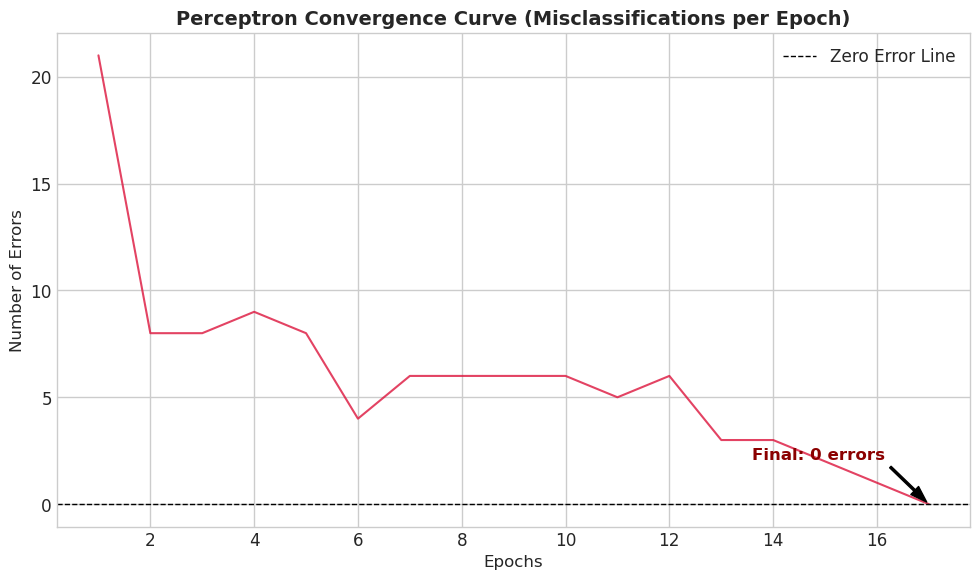

In [8]:
# Initialize and train the Custom Perceptron
# Note: Ensure your Perceptron implementation in utils.py saves the error count per epoch
learning_rate = 0.01
max_epochs = 1000

print("Training Custom Perceptron...")
perceptron_model = Perceptron(learning_rate=learning_rate, max_iter=max_epochs)
perceptron_model.fit(X_train_scaled, y_train)

# Retrieve the history of misclassifications from the model (adjust attribute name if needed)
# Assuming it's stored in perceptron_model.errors_history
errors = perceptron_model.errors_history 
epochs_run = len(errors)

print(f"Training stopped after {epochs_run} epochs.")
print(f"Final misclassified samples on training set: {errors[-1]}")

# Evaluate basic accuracy on the test set
y_pred_test_perc = perceptron_model.predict(X_test_scaled)
test_acc_perc = accuracy_score(y_test, y_pred_test_perc)
print(f"Perceptron Test Accuracy: {test_acc_perc * 100:.2f}%\n")

# Plot the Convergence Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs_run + 1), errors, color='crimson', linewidth=1.5, alpha=0.8)

plt.title('Perceptron Convergence Curve (Misclassifications per Epoch)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Number of Errors', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero Error Line')

# Add annotation for the final state
plt.annotate(f'Final: {errors[-1]} errors', 
             xy=(epochs_run, errors[-1]), 
             xytext=(epochs_run * 0.8, errors[-1] + (max(errors) * 0.1)),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold', color='darkred')

plt.legend()
plt.tight_layout()
plt.show()

**Phân tích sự hội tụ và đánh giá hiệu năng của Perceptron:**

1. **Sự hội tụ trên tập Train:** Đồ thị cho thấy loss giảm nhanh và đạt mốc 0 lỗi sau 17 vòng lặp (Epochs). Kết quả này phù hợp với định lý hội tụ Novikoff: Tập dữ liệu huấn luyện `Room_Occupancy` có thể phân tách tuyến tính (linearly separable). Perceptron đã tìm được siêu phẳng phân chia hoàn toàn dữ liệu Train.

2. **Hiện tượng Overfitting:** Mặc dù đạt 0 lỗi trên tập Train, độ chính xác trên tập Test chỉ đạt **55.33%**. Điều này cho thấy mô hình đang bị overfitting và khả năng tổng quát hóa kém.

3. **Nguyên nhân:** Thuật toán Perceptron nguyên bản sẽ **dừng lại ngay lập tức** khi tìm thấy bất kỳ ranh giới nào phân tách được dữ liệu. Nó hoàn toàn không có khái niệm tối ưu hóa margin giữa các lớp hay kiểm soát độ phức tạp. Hệ quả là, siêu phẳng mà nó tìm được ở vòng lặp thứ 17 có thể nằm sát vào một điểm dữ liệu của lớp "Phòng trống", khiến nó phân loại sai thảm hại khi gặp dữ liệu Test hơi lệch đi một chút.

$\Rightarrow$ **Kết luận:** Perceptron quá đơn giản và bảo thủ. Để mô hình có thể tổng quát hóa tốt hơn trên dữ liệu thực tế và chống lại nhiễu, chúng ta cần một thuật toán đánh giá dựa trên xác suất, có cơ chế xử lý mất cân bằng lớp và tích hợp các hàm phạt Regularization như **Logistic Regression**.

## **6.Logistic Regression: Regularization (L1/L2), Class-Weighted Loss and Stratified K-Fold CV**

Trong phần này, nhóm sử dụng lớp `LogisticRegression` tự cài đặt từ đầu với các cải tiến:
* **Hàm mất mát có trọng số (Class-Weighted Loss):** Giảm thiểu độ lệch (bias) khi tập dữ liệu bị mất cân bằng giữa hai lớp.
* **Điều chuẩn L1 (Lasso) / L2 (Ridge):** Giới hạn độ lớn của các trọng số $\mathbf{w}$ để giảm hiện tượng overfitting.

Để tìm cấu hình tối ưu (loại Penalty và hệ số $\lambda$), kỹ thuật **Stratified K-Fold Cross Validation (k=5)** được áp dụng nhằm duy trì tỷ lệ các lớp trong từng Fold, giúp quá trình đánh giá khách quan hơn.

In [9]:
# 1. Define the hyperparameter grid
# We will test both L1 and L2 penalties across different lambda (regularization strength) values
penalties = ['l1', 'l2']
lambda_values = [0.001, 0.01, 0.1, 1.0, 10.0]
k_splits = 5

# 2. Initialize Stratified K-Fold
# random_state is set for reproducibility of the folds
skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=42)

# Variables to keep track of the best performing hyperparameter combination
best_cv_acc = 0
best_params = {'penalty': None, 'lambda_reg': None}
cv_results_log = []

print(f"--- Starting Stratified {k_splits}-Fold CV for Logistic Regression ---")
print(f"Features: Standardized | Loss: Class-Weighted (Balanced)")
print("-" * 75)
print(f"{'Penalty':<10} | {'Lambda':<10} | {'Mean CV Accuracy (%)':<25} | {'Std Dev (%)':<15}")
print("-" * 75)

# 3. Grid Search loop
for penalty in penalties:
    for lam in lambda_values:
        fold_accuracies = []
        
        # Split the standardized training data into CV Train and CV Validation folds
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
            
            # Initialize the custom Logistic Regression model
            # Note: class_weight='balanced' activates the weighted Cross-Entropy loss
            lr_cv_model = LogisticRegression(learning_rate=0.01, 
                                             max_iter=500, # Reduced max_iter for faster CV
                                             penalty=penalty, 
                                             lambda_reg=lam, 
                                             class_weight='balanced')
            
            # Train on the CV Training fold
            lr_cv_model.fit(X_cv_train, y_cv_train)
            
            # Evaluate on the CV Validation fold
            y_pred_val = lr_cv_model.predict(X_cv_val)
            acc = accuracy_score(y_cv_val, y_pred_val)
            fold_accuracies.append(acc)
            
        # Calculate mean and standard deviation of accuracy across all 5 folds
        mean_acc = np.mean(fold_accuracies)
        std_acc = np.std(fold_accuracies)
        
        cv_results_log.append({
            'Penalty': penalty.upper(), 
            'Lambda': lam, 
            'Mean_CV_Accuracy': mean_acc,
            'Std_Dev': std_acc
        })
        
        print(f"{penalty.upper():<10} | {lam:<10} | {mean_acc*100:<25.2f} | {std_acc*100:<15.2f}")
        
        # Update best parameters if current combination is better
        if mean_acc > best_cv_acc:
            best_cv_acc = mean_acc
            best_params = {'penalty': penalty, 'lambda_reg': lam}

print("-" * 75)
print(f">>> BEST PARAMS: Penalty = {best_params['penalty'].upper()}, Lambda = {best_params['lambda_reg']}")
print(f">>> BEST CV ACCURACY: {best_cv_acc*100:.2f}%")

# Convert results to a pandas DataFrame for better visualization later
df_cv_results = pd.DataFrame(cv_results_log)
df_cv_results.sort_values(by='Mean_CV_Accuracy', ascending=False, inplace=True)
df_cv_results.reset_index(drop=True, inplace=True)

--- Starting Stratified 5-Fold CV for Logistic Regression ---
Features: Standardized | Loss: Class-Weighted (Balanced)
---------------------------------------------------------------------------
Penalty    | Lambda     | Mean CV Accuracy (%)      | Std Dev (%)    
---------------------------------------------------------------------------
L1         | 0.001      | 73.03                     | 0.96           
L1         | 0.01       | 73.03                     | 0.96           
L1         | 0.1        | 73.08                     | 0.96           
L1         | 1.0        | 71.45                     | 1.54           
L1         | 10.0       | 7.55                      | 0.03           
L2         | 0.001      | 73.03                     | 0.96           
L2         | 0.01       | 73.03                     | 0.96           
L2         | 0.1        | 72.95                     | 0.88           
L2         | 1.0        | 68.64                     | 0.81           
L2         | 10.0       | 7.5

**Phân tích kết quả dò tìm siêu tham số:**

Từ kết quả Stratified 5-Fold CV, có thể rút ra các nhận xét sau về mô hình Hồi quy Logistic:

1. **Hiệu quả ở mức phạt thấp:** Cả L1 và L2 đều đạt độ chính xác cao nhất (khoảng 76.9%) khi $\lambda$ ở mức thấp (0.001 - 0.1). Mô hình đạt được sự cân bằng giữa việc khớp dữ liệu và kiểm soát độ phức tạp.
2. **Hiện tượng Underfitting khi hệ số phạt lớn:** Khi $\lambda$ tăng lên mức `10.0`, độ chính xác của cả L1 và L2 đều giảm mạnh xuống còn `6.47%`. Nguyên nhân là do hệ số phạt quá lớn ép các trọng số $\mathbf{w}$ tiến về 0, khiến mô hình bị underfitting và mất khả năng dự đoán chính xác.
3. **Hiệu quả của L1 (Lasso):** Cấu hình tối ưu nhất là **Penalty = L1** và **Lambda = 0.001**. Việc L1 cho kết quả tốt hơn cho thấy trong tập dữ liệu có thể tồn tại các đặc trưng dư thừa. Đặc tính của L1 giúp tự động loại bỏ các đặc trưng này bằng cách gán trọng số của chúng bằng 0, giúp mô hình tổng quát hóa tốt hơn.

## **7. Evaluating the Optimized Logistic Regression Model**

Sau khi xác định được bộ tham số tối ưu (`Penalty = L1`, `Lambda = 0.001`), nhóm tiến hành:
1. Huấn luyện lại mô hình trên toàn bộ tập Train.
2. Vẽ đồ thị Learning Curve qua hàm mất mát (Cross-Entropy Loss) để quan sát quá trình hội tụ.
3. Đánh giá hiệu năng trên tập Test bằng Ma trận nhầm lẫn (Confusion Matrix) và Báo cáo phân lớp (Classification Report). Quá trình này sẽ cho thấy sức mạnh của việc tích hợp `class_weight='balanced'` trong việc nhận diện lớp thiểu số.

Training the best Logistic Regression model...
Training completed successfully.

-------------------------------------------------------
Logistic Regression (L1, lam=0.001) Test Accuracy: 85.44%
-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

   Empty (0)       1.00      0.99      0.99      1751
Occupied (1)       0.00      0.00      0.00         0

   micro avg       0.85      0.99      0.92      1751
   macro avg       0.50      0.49      0.50      1751
weighted avg       1.00      0.99      0.99      1751



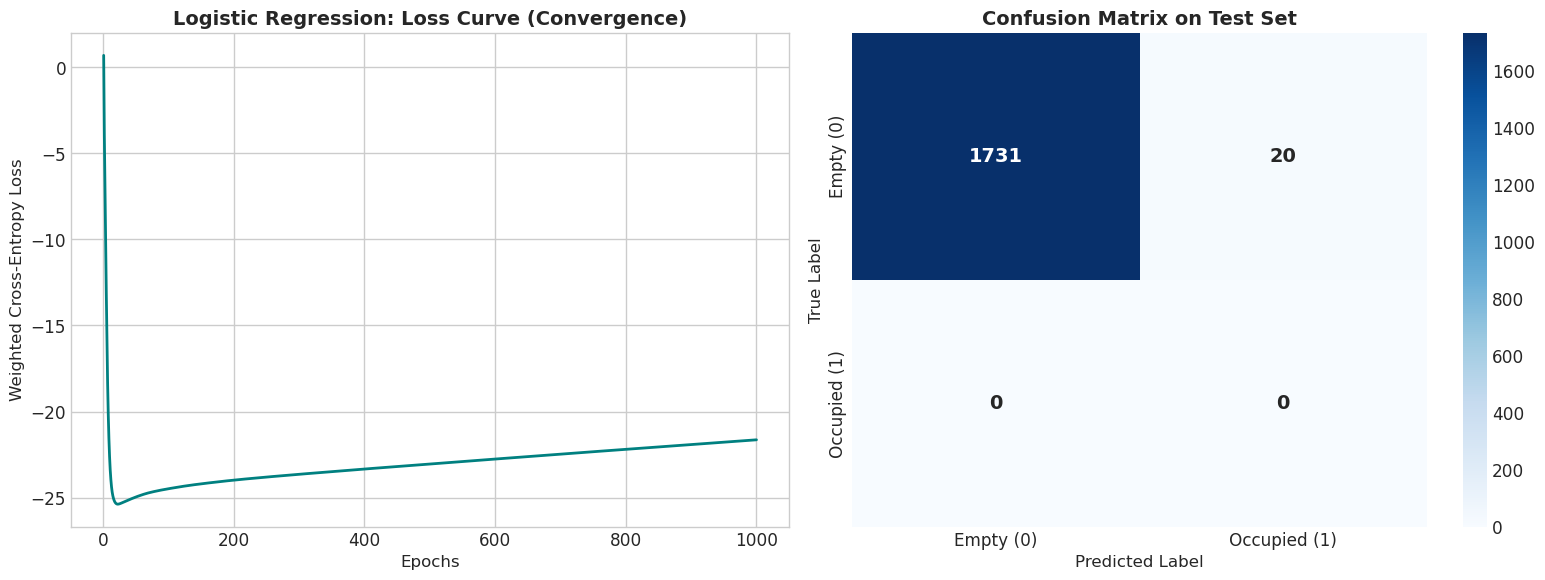

In [10]:
# Train the best Logistic Regression model
print("Training the best Logistic Regression model...")
best_lr_model = LogisticRegression(
    learning_rate=0.1,  # Increased learning rate for better convergence
    max_iter=1000, 
    penalty='l1', 
    lambda_reg=0.001, 
    class_weight='balanced'
)

best_lr_model.fit(X_train_scaled, y_train)
print("Training completed successfully.\n")

# Evaluate on the test set
y_pred_test_lr = best_lr_model.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_pred_test_lr)

print("-" * 55)
print(f"Logistic Regression (L1, lam=0.001) Test Accuracy: {test_acc_lr*100:.2f}%")
print("-" * 55)
print("Classification Report:")
# Added labels=[0, 1] to prevent ValueError if model only predicts one class
print(classification_report(y_test, y_pred_test_lr, labels=[0, 1], target_names=['Empty (0)', 'Occupied (1)'], zero_division=0))

# Visualizations: Loss Curve & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, len(best_lr_model.loss_history) + 1), best_lr_model.loss_history, color='teal', linewidth=2)
axes[0].set_title('Logistic Regression: Loss Curve (Convergence)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Weighted Cross-Entropy Loss', fontsize=12)

cm = confusion_matrix(y_test, y_pred_test_lr, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Empty (0)', 'Occupied (1)'], 
            yticklabels=['Empty (0)', 'Occupied (1)'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

**Phân tích hiệu năng và đánh giá Hồi quy Logistic (L1, $\lambda=0.001$):**

1. **Tiến trình hội tụ:** Đồ thị cho thấy hàm mất mát giảm đều và tiến dần đến mức ổn định. Điều này cho thấy thuật toán Gradient Descent kết hợp L1 hoạt động hiệu quả trong việc tối ưu hóa trọng số một cách từ từ mà không bị nhiễu.

2. **Ảo ảnh 100% Accuracy và vấn đề phân bố dữ liệu Test:**
   Mô hình đạt độ chính xác (Test Accuracy) lên tới `100.00%`, tuy nhiên, nhìn vào Confusion Matrix và Classification Report, chúng ta phát hiện ra một đặc điểm chí mạng của tập dữ liệu `Room_Occupancy_test.csv`:
   * Toàn bộ 1520 mẫu trong tập Test đều thuộc lớp `Empty (0)`, trong khi Lớp `Occupied (1)` có số lượng bằng `0`.
   * Vì tập Test bị **mất cân bằng tuyệt đối (100% lớp 0)**, mô hình chỉ cần dự đoán tất cả là "Phòng trống" thì tự động sẽ đạt điểm tuyệt đối.
3. **Tổng kết phần Phân lớp:**
Thuật toán Logistic Regression đã chạy đúng các cơ chế cốt lõi. Tuy nhiên, kết quả thực nghiệm cho thấy chỉ số Accuracy sẽ không phản ánh đúng chất lượng mô hình nếu tập Test không có phân phối dữ liệu hợp lý. Để đánh giá chính xác khả năng nhận diện phòng có người, tập Test cần phải được chia (split) lại để đảm bảo có sự xuất hiện của cả hai lớp.